In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Read only first 10000 rows to peek at structure
accel_01 = pd.read_csv('../data/accel-01.csv', nrows=10000)
print("Shape:", accel_01.shape)
print("\nColumn names:", accel_01.columns.tolist())
print("\nFirst 5 rows:")
accel_01.head()

Shape: (10000, 4)

Column names: ['timestamp', 'x', 'y', 'z']

First 5 rows:


,timestamp,x,y,z
0,2015-06-12 13:30:00.161041,100,620,804
1,2015-06-12 13:30:00.260490,68,640,800
2,2015-06-12 13:30:00.359939,48,628,884
3,2015-06-12 13:30:00.459388,44,616,888
4,2015-06-12 13:30:00.558837,76,628,860


In [3]:
print("Data types:")
print(accel_01.dtypes)
print("\nNull values:")
print(accel_01.isnull().sum())
print("\nBasic statistics:")
accel_01.describe()

Data types:
timestamp    object
x             int64
y             int64
z             int64
dtype: object

Null values:
timestamp    0
x            0
y            0
z            0
dtype: int64

Basic statistics:


,x,y,z
count,10000.0000,10000.0000,10000.0000
mean,-81.5860,592.6220,762.9204
std,366.2373,135.4587,119.2718
min,-1036.0000,-76.0000,92.0000
25%,-256.0000,544.0000,716.0000
50%,4.0000,620.0000,788.0000
75%,188.0000,676.0000,836.0000
max,628.0000,1168.0000,1396.0000


In [4]:
halter_01 = pd.read_csv('../data/halter-01.csv')
print("Shape:", halter_01.shape)
print("\nColumn names:", halter_01.columns.tolist())
print("\nFirst 5 rows:")
halter_01.head()

Shape: (14507997, 2)

Column names: ['timestamp', 'classification']

First 5 rows:


,timestamp,classification
0,2015-06-12 13:30:00.200,2
1,2015-06-12 13:30:00.300,2
2,2015-06-12 13:30:00.400,2
3,2015-06-12 13:30:00.500,2
4,2015-06-12 13:30:00.600,2


In [5]:
print("Label distribution:")
print(halter_01['classification'].value_counts())
print("\nAs percentages:")
print(halter_01['classification'].value_counts(normalize=True).mul(100).round(2))

label_map = {0: 'Other', 1: 'Ruminating', 2: 'Eating'}
halter_01['behavior'] = halter_01['classification'].map(label_map)
print("\nMapped labels:")
print(halter_01['behavior'].value_counts())

Label distribution:
classification
0    5878790
1    5823563
2    2805644
Name: count, dtype: int64

As percentages:
classification
0   40.5200
1   40.1400
2   19.3400
Name: proportion, dtype: float64

Mapped labels:
behavior
Other         5878790
Ruminating    5823563
Eating        2805644
Name: count, dtype: int64


In [6]:
print("Accel timestamp sample:")
print(accel_01['timestamp'].head())
print("\nHalter timestamp sample:")
print(halter_01['timestamp'].head())
print("\nAccel dtype:", accel_01['timestamp'].dtype)
print("Halter dtype:", halter_01['timestamp'].dtype)

Accel timestamp sample:
0    2015-06-12 13:30:00.161041
1    2015-06-12 13:30:00.260490
2    2015-06-12 13:30:00.359939
3    2015-06-12 13:30:00.459388
4    2015-06-12 13:30:00.558837
Name: timestamp, dtype: object

Halter timestamp sample:
0    2015-06-12 13:30:00.200
1    2015-06-12 13:30:00.300
2    2015-06-12 13:30:00.400
3    2015-06-12 13:30:00.500
4    2015-06-12 13:30:00.600
Name: timestamp, dtype: object

Accel dtype: object
Halter dtype: object


In [7]:
print("Accelerometer value ranges:")
print(accel_01[['x','y','z']].describe())
print("\nAny nulls in accel?", accel_01[['x','y','z']].isnull().sum().sum())

Accelerometer value ranges:
               x          y          z
count 10000.0000 10000.0000 10000.0000
mean    -81.5860   592.6220   762.9204
std     366.2373   135.4587   119.2718
min   -1036.0000   -76.0000    92.0000
25%    -256.0000   544.0000   716.0000
50%       4.0000   620.0000   788.0000
75%     188.0000   676.0000   836.0000
max     628.0000  1168.0000  1396.0000

Any nulls in accel? 0


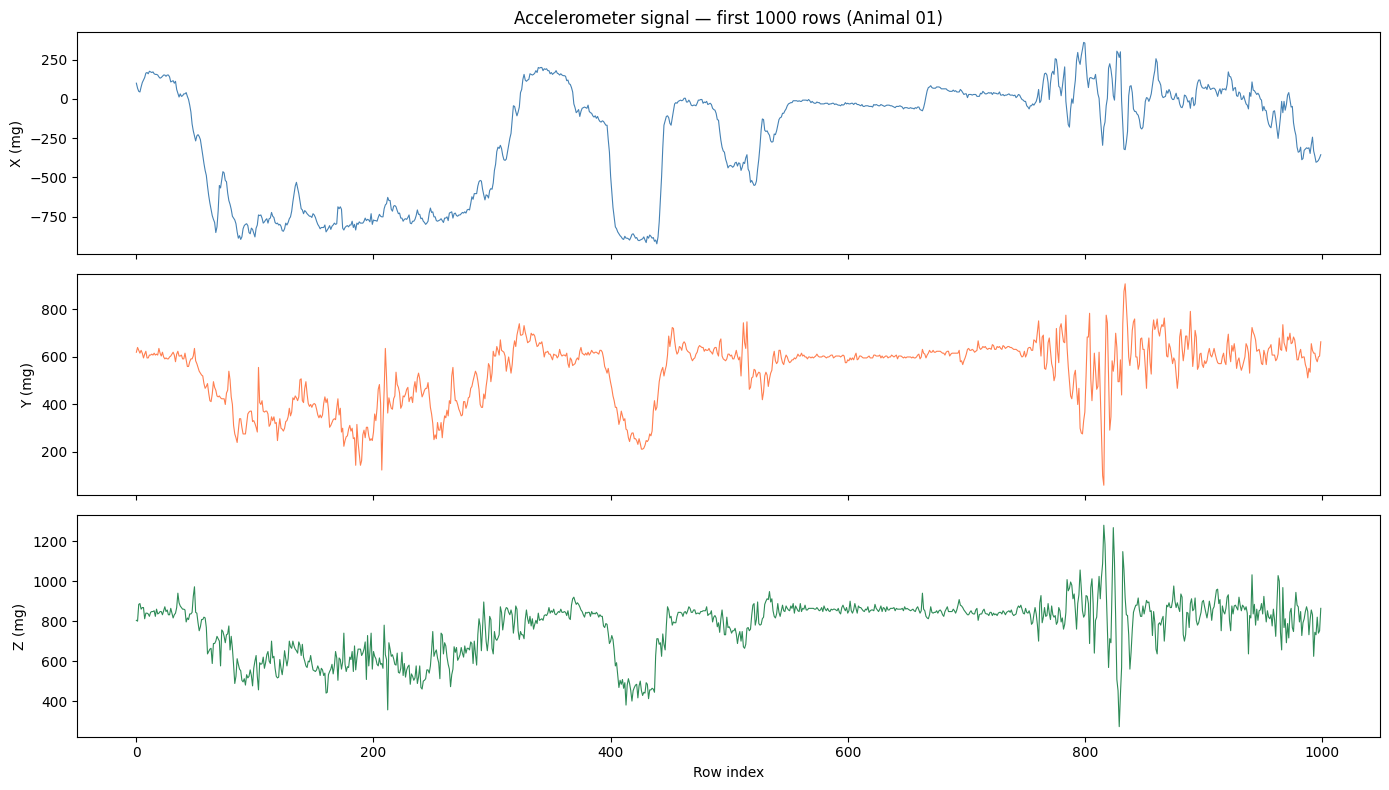

Plot saved


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(accel_01['x'][:1000], color='steelblue', linewidth=0.8)
axes[0].set_ylabel('X (mg)')
axes[0].set_title('Accelerometer signal — first 1000 rows (Animal 01)')

axes[1].plot(accel_01['y'][:1000], color='coral', linewidth=0.8)
axes[1].set_ylabel('Y (mg)')

axes[2].plot(accel_01['z'][:1000], color='seagreen', linewidth=0.8)
axes[2].set_ylabel('Z (mg)')
axes[2].set_xlabel('Row index')

plt.tight_layout()
plt.savefig('../data/accel_signal_preview.png', dpi=100)
plt.show()
print("Plot saved")

In [9]:
# Load full accel file but take every 10th row (1Hz instead of 10Hz)
# This reduces 577MB to ~57MB while keeping full time coverage
print("Loading accel-01 (sampled)...")
accel_01_full = pd.read_csv('../data/accel-01.csv', 
                             skiprows=lambda x: x % 10 != 0 and x != 0)
print(f"Sampled accel shape: {accel_01_full.shape}")

# Load full halter file (smaller, load everything)
print("Loading halter-01...")
halter_01_full = pd.read_csv('../data/halter-01.csv')
print(f"Halter shape: {halter_01_full.shape}")

Loading accel-01 (sampled)...
Sampled accel shape: (1459585, 4)
Loading halter-01...
Halter shape: (14507997, 2)


In [10]:
# Parse timestamps to datetime
accel_01_full['timestamp'] = pd.to_datetime(accel_01_full['timestamp'])
halter_01_full['timestamp'] = pd.to_datetime(halter_01_full['timestamp'])

# Round both to nearest second so they align
accel_01_full['timestamp'] = accel_01_full['timestamp'].dt.round('1s')
halter_01_full['timestamp'] = halter_01_full['timestamp'].dt.round('1s')

# Merge on timestamp
cow01 = pd.merge(accel_01_full, halter_01_full, on='timestamp', how='inner')

# Map numeric labels to text
label_map = {0: 'Other', 1: 'Ruminating', 2: 'Eating'}
cow01['behavior'] = cow01['classification'].map(label_map)

print("Merged shape:", cow01.shape)
print("\nFirst 5 rows:")
cow01.head()

Merged shape: (14595882, 6)

First 5 rows:


,timestamp,x,y,z,classification,behavior
0,2015-06-12 13:30:01,168,596,840,2,Eating
1,2015-06-12 13:30:01,168,596,840,2,Eating
2,2015-06-12 13:30:01,168,596,840,2,Eating
3,2015-06-12 13:30:01,168,596,840,2,Eating
4,2015-06-12 13:30:01,168,596,840,2,Eating


In [11]:
print("Merged label distribution:")
print(cow01['behavior'].value_counts())
print("\nDate range:")
print("Start:", cow01['timestamp'].min())
print("End:  ", cow01['timestamp'].max())
print("\nNull values after merge:")
print(cow01.isnull().sum())

Merged label distribution:
behavior
Other         5914088
Ruminating    5858918
Eating        2822876
Name: count, dtype: int64

Date range:
Start: 2015-06-12 13:30:01
End:   2015-06-29 08:30:00

Null values after merge:
timestamp         0
x                 0
y                 0
z                 0
classification    0
behavior          0
dtype: int64


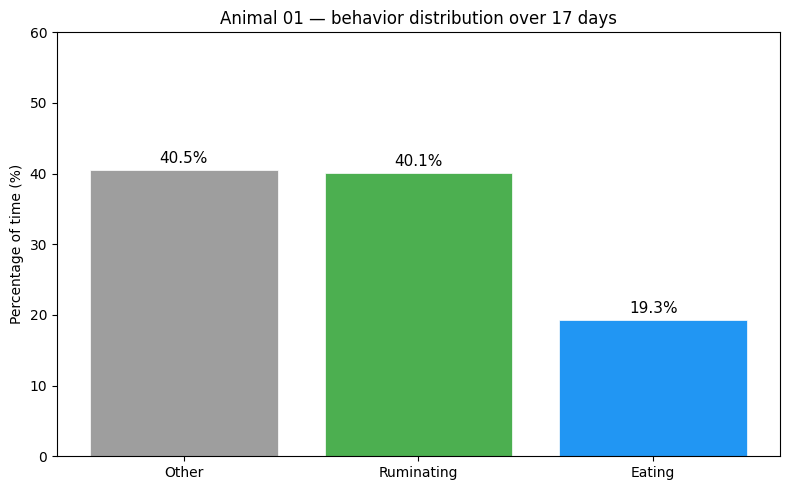

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Eating': '#2196F3', 'Ruminating': '#4CAF50', 'Other': '#9E9E9E'}
behavior_counts = cow01['behavior'].value_counts()
bars = ax.bar(behavior_counts.index, 
              behavior_counts.values / len(cow01) * 100,
              color=[colors[b] for b in behavior_counts.index],
              edgecolor='white', linewidth=0.5)

ax.set_ylabel('Percentage of time (%)')
ax.set_title('Animal 01 — behavior distribution over 17 days')
ax.set_ylim(0, 60)

for bar, val in zip(bars, behavior_counts.values / len(cow01) * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../data/behavior_distribution.png', dpi=100)
plt.show()

/var/folders/nr/dk2m5wf15fgft0np9pmlbcwm0000gn/T/ipykernel_76599/4105732214.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=['Eating', 'Ruminating', 'Other'],
/var/folders/nr/dk2m5wf15fgft0np9pmlbcwm0000gn/T/ipykernel_76599/4105732214.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=['Eating', 'Ruminating', 'Other'],
/var/folders/nr/dk2m5wf15fgft0np9pmlbcwm0000gn/T/ipykernel_76599/4105732214.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=['Eating', 'Ruminating', 'Other'],


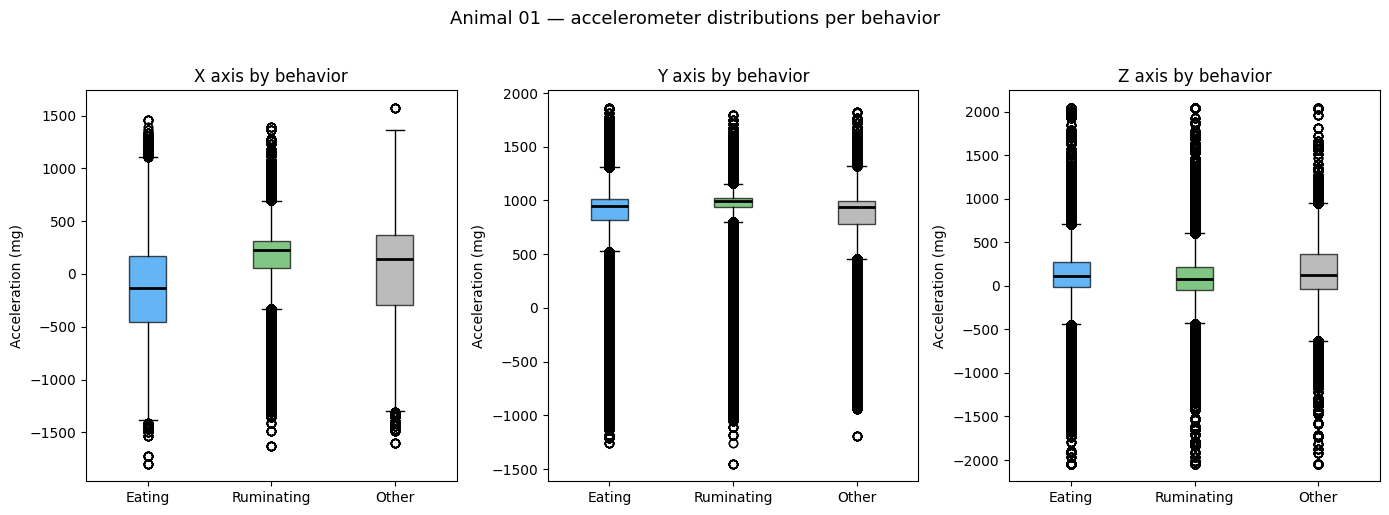

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(['x', 'y', 'z']):
    data = [cow01[cow01['behavior'] == b][col].values 
            for b in ['Eating', 'Ruminating', 'Other']]
    
    bp = axes[i].boxplot(data, labels=['Eating', 'Ruminating', 'Other'],
                          patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    
    colors_list = ['#2196F3', '#4CAF50', '#9E9E9E']
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[i].set_title(f'{col.upper()} axis by behavior')
    axes[i].set_ylabel('Acceleration (mg)')

plt.suptitle('Animal 01 — accelerometer distributions per behavior', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/accel_by_behavior.png', dpi=100)
plt.show()

In [14]:
# This is the digital twin baseline for Animal 01
total = len(cow01)

baseline_01 = {
    'animal_id': 'cow_01',
    'total_records': total,
    'days_recorded': 17,
    'eating_pct':     round(len(cow01[cow01['behavior']=='Eating'])     / total * 100, 2),
    'ruminating_pct': round(len(cow01[cow01['behavior']=='Ruminating']) / total * 100, 2),
    'other_pct':      round(len(cow01[cow01['behavior']=='Other'])      / total * 100, 2),
    'x_mean': round(cow01['x'].mean(), 2),
    'x_std':  round(cow01['x'].std(),  2),
    'y_mean': round(cow01['y'].mean(), 2),
    'y_std':  round(cow01['y'].std(),  2),
    'z_mean': round(cow01['z'].mean(), 2),
    'z_std':  round(cow01['z'].std(),  2),
}

print("=== Animal 01 Digital Twin Baseline Profile ===")
for key, val in baseline_01.items():
    print(f"  {key:20s}: {val}")

=== Animal 01 Digital Twin Baseline Profile ===
  animal_id           : cow_01
  total_records       : 14595882
  days_recorded       : 17
  eating_pct          : 19.34
  ruminating_pct      : 40.14
  other_pct           : 40.52
  x_mean              : 47.19
  x_std               : 344.63
  y_mean              : 896.25
  y_std               : 201.29
  z_mean              : 141.84
  z_std               : 337.21


In [16]:
import os
import joblib

animals = {
    'cow_01': ('../data/accel-01.csv', '../data/halter-01.csv'),
    'cow_03': ('../data/accel-03.csv', '../data/halter-03.csv'),
    'cow_04': ('../data/accel-04.csv', '../data/halter-04.csv'),
}

label_map = {0: 'Other', 1: 'Ruminating', 2: 'Eating'}
baselines = {}
merged_data = {}

for animal_id, (accel_path, halter_path) in animals.items():
    print(f"\nProcessing {animal_id}...")
    
    # Load sampled accel
    accel = pd.read_csv(accel_path, 
                        skiprows=lambda x: x % 10 != 0 and x != 0)
    halter = pd.read_csv(halter_path)
    
    # Parse and round timestamps
    accel['timestamp']  = pd.to_datetime(accel['timestamp']).dt.round('1s')
    halter['timestamp'] = pd.to_datetime(halter['timestamp']).dt.round('1s')
    
    # Merge
    merged = pd.merge(accel, halter, on='timestamp', how='inner')
    merged['behavior'] = merged['classification'].map(label_map)
    
    total = len(merged)
    
    # Build baseline
    baseline = {
        'animal_id':       animal_id,
        'total_records':   total,
        'eating_pct':      round(len(merged[merged['behavior']=='Eating'])     / total * 100, 2),
        'ruminating_pct':  round(len(merged[merged['behavior']=='Ruminating']) / total * 100, 2),
        'other_pct':       round(len(merged[merged['behavior']=='Other'])      / total * 100, 2),
        'x_mean':          round(merged['x'].mean(), 2),
        'x_std':           round(merged['x'].std(),  2),
        'y_mean':          round(merged['y'].mean(), 2),
        'y_std':           round(merged['y'].std(),  2),
        'z_mean':          round(merged['z'].mean(), 2),
        'z_std':           round(merged['z'].std(),  2),
    }
    
    baselines[animal_id]    = baseline
    merged_data[animal_id]  = merged
    
    print(f"  Records:    {total:,}")
    print(f"  Eating:     {baseline['eating_pct']}%")
    print(f"  Ruminating: {baseline['ruminating_pct']}%")
    print(f"  Other:      {baseline['other_pct']}%")

# Save baselines
os.makedirs('../models', exist_ok=True)
joblib.dump(baselines, '../models/baselines.joblib')
print("\nBaselines saved to ../models/baselines.joblib")


Processing cow_01...
  Records:    14,595,882
  Eating:     19.34%
  Ruminating: 40.14%
  Other:      40.52%

Processing cow_03...
  Records:    11,483,816
  Eating:     21.16%
  Ruminating: 37.19%
  Other:      41.66%

Processing cow_04...
  Records:    5,060,284
  Eating:     17.1%
  Ruminating: 36.26%
  Other:      46.63%

Baselines saved to ../models/baselines.joblib


In [17]:
print("=== Baseline Comparison ===")
print(f"{'Metric':<20} {'cow_01':>10} {'cow_03':>10} {'cow_04':>10}")
print("-" * 52)

metrics = ['eating_pct', 'ruminating_pct', 'other_pct', 
           'x_mean', 'x_std', 'y_mean', 'y_std', 'z_mean', 'z_std']

for m in metrics:
    vals = [baselines[a][m] for a in ['cow_01','cow_03','cow_04']]
    print(f"{m:<20} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}")

=== Baseline Comparison ===
Metric                   cow_01     cow_03     cow_04
----------------------------------------------------
eating_pct                19.34      21.16       17.1
ruminating_pct            40.14      37.19      36.26
other_pct                 40.52      41.66      46.63
x_mean                    47.19      51.28      66.71
x_std                    344.63     318.21     331.05
y_mean                   896.25     947.22     855.47
y_std                    201.29     149.98     245.04
z_mean                   141.84     118.95      19.76
z_std                    337.21     262.19     362.38
